In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
wav_path = 'train_data/0.wav'
train_df = pd.read_csv('train_data.csv')['answer'].apply(lambda x: x[1:-1])
train_df

0        967153686617
1        475237568072
2        554532815990
3      62700892530689
4       2065995398890
            ...      
295     8885008716550
296     6459814146833
297     5735698685824
298     1572821551463
299     7203147258896
Name: answer, Length: 300, dtype: str

# Plots

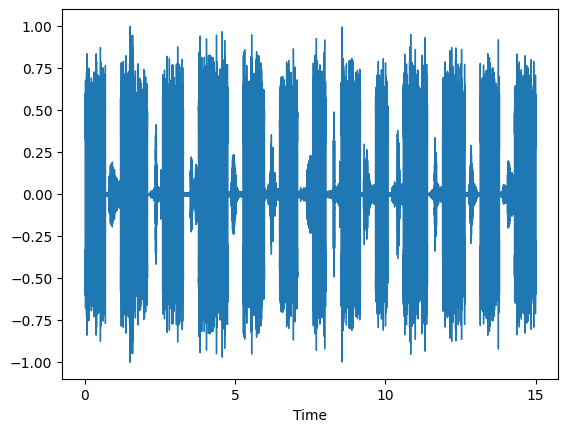

In [2]:
import librosa
SR = 48000
y, _ = librosa.load(wav_path, sr=SR)
librosa.display.waveshow(y, sr=SR)

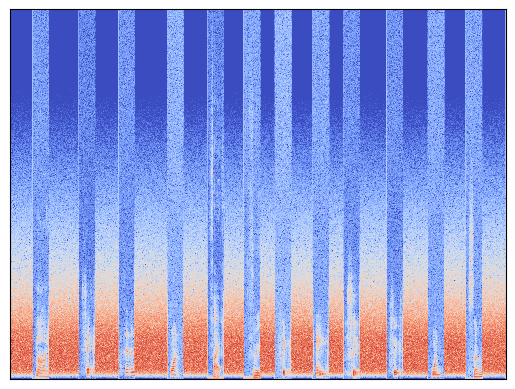

In [3]:
D = librosa.stft(y)
db = librosa.amplitude_to_db(abs(D))
librosa.display.specshow(db, sr=SR)

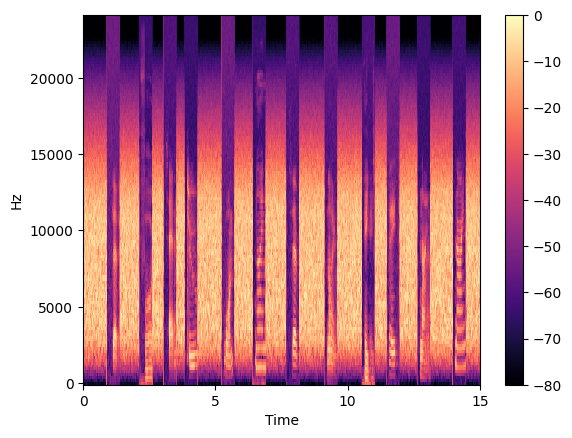

In [20]:
y, _ = librosa.load('train_data/100.wav', sr=SR)
mel = librosa.feature.melspectrogram(y=y, sr=SR)
db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(db, sr=SR, x_axis='time', y_axis='hz')
plt.colorbar()

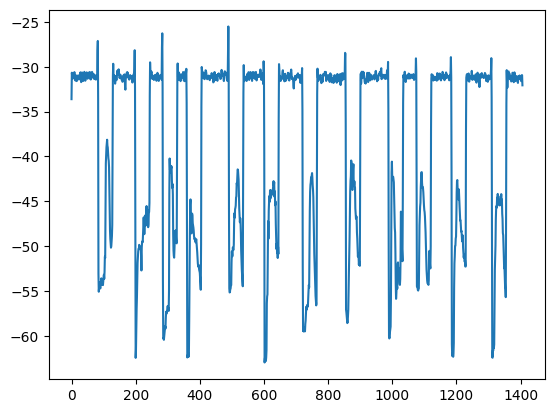

In [22]:
frame_energy = np.mean(db, axis=0)
plt.plot(frame_energy)

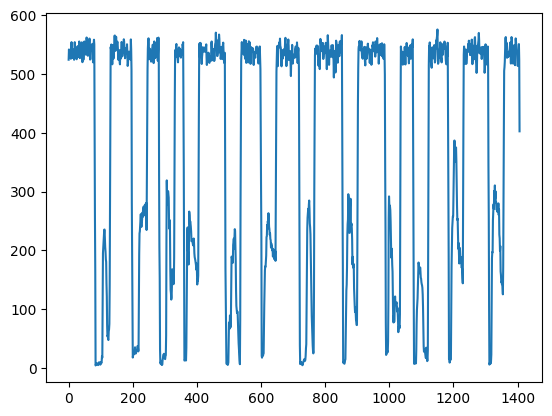

In [23]:
plt.plot(np.var(db, axis=0))

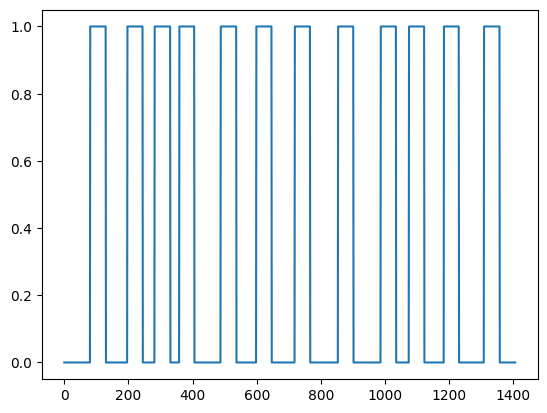

In [21]:
y, _ = librosa.load(os.path.join('train_data', '100.wav'), sr=SR)
mel = librosa.feature.melspectrogram(y=y, sr=SR)
db = librosa.power_to_db(mel, ref=np.max)
mask = np.var(db, axis=0) < 400
plt.plot(mask)

In [ ]:
masks = []
start, end = 0, 0
started = False
for i, bin in enumerate(mask):
    if not started and bin:
        started = True
        start = i
    elif started and not bin:
        started = False
        end = i
        if end-start > 5:
            masks.append(range(start, end))

masks

14

In [24]:
train_df.iloc[100]

'747219798899'

# Task

In [18]:
def get_masks(db):
    mask = np.var(db, axis=0) < 400
    masks = []
    start, end = 0, 0
    started = False
    for i, bin in enumerate(mask):
        if not started and bin:
            started = True
            start = i
        elif started and not bin:
            started = False
            end = i
            if end-start > 5:
                masks.append(range(start, end))
    
    return masks

wav_files = os.listdir('train_data')
mels = []
for i, wav_name in enumerate(wav_files):
    y, _ = librosa.load(os.path.join('train_data', wav_name), sr=SR)
    mel = librosa.feature.melspectrogram(y=y, sr=SR)
    db = librosa.power_to_db(mel, ref=np.max)
    masks = get_masks(db)
    dbs = [db[:, mask] for mask in masks]
    if len(masks) != len(train_df.iloc[i]):
        print(f'at index {wav_name}: {len(masks)} vs {len(train_df.iloc[i])}')


at index 100.wav: 12 vs 14
at index 102.wav: 11 vs 12
at index 103.wav: 11 vs 12
at index 106.wav: 13 vs 12
at index 107.wav: 13 vs 12
at index 110.wav: 13 vs 12
at index 111.wav: 11 vs 13
at index 112.wav: 14 vs 13
at index 114.wav: 13 vs 14
at index 116.wav: 14 vs 13
at index 117.wav: 12 vs 13
at index 118.wav: 12 vs 13
at index 119.wav: 13 vs 12
at index 120.wav: 12 vs 14
at index 121.wav: 12 vs 13
at index 122.wav: 13 vs 12
at index 123.wav: 11 vs 12
at index 125.wav: 13 vs 14
at index 126.wav: 14 vs 13
at index 128.wav: 13 vs 12
at index 130.wav: 12 vs 11
at index 131.wav: 13 vs 12
at index 132.wav: 13 vs 12


KeyboardInterrupt: 

In [ ]:
mask = db[-1,:] != -80
masks = []
start, end = 0, 0
started = False
for i, bin in enumerate(mask):
    if not started and bin:
        started = True
        start = i
    elif started and not bin:
        started = False
        end = i
        masks.append(range(start, end))



(12, 12)